In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install dowhy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 22.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [ ]:
import pandas as pd
import numpy as np
import os
import dowhy
from dowhy import CausalModel
import warnings
warnings.filterwarnings('ignore')

# 1. 加载最稳定的 RF MICE 数据集
drive_data_folder = '/content/drive/MyDrive/Colab Notebooks/DDA4210/DataSet'
df = pd.read_csv(os.path.join(drive_data_folder, 'NHANES_Imp_RF.csv'))

# 构造重度抑郁标签 (DoWhy 处理二分类干预时强烈建议使用 bool 类型)
df['Severe_MDD'] = (df['PHQ9_Score'] >= 15).astype(bool)

# =====================================================================
# 定义核心 DoWhy 自动化封装函数 (极大提升代码工程化水平)
# =====================================================================
def evaluate_causal_path(df, treatment, outcome, confounders, is_treatment_binary=False):
    print(f"\n" + "="*60)
    print(f"正在评估路径: [{treatment}] ──指向──> [{outcome}]")
    print(f"控制的混杂因子 (Confounders): {confounders}")
    print("="*60)

    # Step 1: 构建模型
    model = CausalModel(
        data=df,
        treatment=treatment,
        outcome=outcome,
        common_causes=confounders
    )

    # Step 2: 识别后门
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

    # Step 3: 估算 ATE
    # 策略区分：如果是二分类干预用 IPTW (更高级)，如果是连续干预用基于回归的后门控制
    if is_treatment_binary:
        method = "backdoor.propensity_score_weighting"
        params = {"weighting_scheme": "ips_weight"}
        print("估算方法: 倾向得分逆概率加权 (IPTW)")
    else:
        method = "backdoor.linear_regression"
        params = {}
        print("估算方法: 基于线性回归的后门控制")

    estimate = model.estimate_effect(
        identified_estimand,
        method_name=method,
        target_units="ate",
        method_params=params
    )

    print(f"\n✅ *** 核心发现 (ATE) ***")
    print(f"每增加 1 个单位的 [{treatment}]，会导致 [{outcome}] 改变: {estimate.value:.4f} 个单位\n")

    # Step 4: 三大敏感性分析 (Refutation Tests)
    print(" 开始敏感性分析 (Robustness Check)...")

    # 4.1 随机安慰剂检验
    refute_placebo = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute"
    )
    print(f"  [1] Placebo Test (安慰剂检验): 预期效应值应接近 0 -> 实际 New Effect: {refute_placebo.new_effect:.4f}")

    # 4.2 子集证伪检验 (删除 20% 样本)
    refute_subset = model.refute_estimate(
        identified_estimand, estimate,
        method_name="data_subset_refuter", subset_fraction=0.8, random_seed=42
    )
    print(f"  [2] Subset Refutation (子集检验): 预期效应值应稳定 -> 实际 New Effect: {refute_subset.new_effect:.4f}")

    # 4.3 未观测混杂因子检验
    refute_unobserved = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause", random_seed=42
    )
    print(f"  [3] Unobserved Confounder (随机混杂因子检验): 预期效应值应稳定 -> 实际 New Effect: {refute_unobserved.new_effect:.4f}")

    return estimate

# =====================================================================
#  依次执行发现的较可信因果路径
# =====================================================================

# 路径 1: 抑郁得分 -> 久坐时间 (连续 -> 连续)
# 混杂因子控制：年龄、性别、收入 (防止收入本身导致的久坐)
est_1 = evaluate_causal_path(
    df=df, treatment='PHQ9_Score', outcome='Sedentary_Mins',
    confounders=['Age', 'Gender', 'Income_Poverty_Ratio'],
    is_treatment_binary=False
)

# 路径 2: 抑郁得分 -> 收入水平 (连续 -> 连续)
# 混杂因子控制：年龄、性别、癌症史 (癌症也会同时导致抑郁和收入下降，必须作为混杂因子控制掉)
est_2 = evaluate_causal_path(
    df=df, treatment='PHQ9_Score', outcome='Income_Poverty_Ratio',
    confounders=['Age', 'Gender', 'Cancer_History'],
    is_treatment_binary=False
)

# 路径 3: 重度抑郁 -> 肥胖程度 (二分类 -> 连续)
# 混杂因子控制：年龄、性别、收入、癌症史 (极其严谨的全面控制)
est_3 = evaluate_causal_path(
    df=df, treatment='Severe_MDD', outcome='BMI',
    confounders=['Age', 'Gender', 'Income_Poverty_Ratio', 'Cancer_History'],
    is_treatment_binary=True
)

print("\n 所有因果效应与鲁棒性检验计算完成 ")


正在评估路径: [PHQ9_Score] ──指向──> [Sedentary_Mins]
控制的混杂因子 (Confounders): ['Age', 'Gender', 'Income_Poverty_Ratio']
估算方法: 基于线性回归的后门控制

✅ *** 核心发现 (ATE) ***
每增加 1 个单位的 [PHQ9_Score]，会导致 [Sedentary_Mins] 改变: 4.0567 个单位

 开始敏感性分析 (Robustness Check)...
  [1] Placebo Test (安慰剂检验): 预期效应值应接近 0 -> 实际 New Effect: -0.0525
  [2] Subset Refutation (子集检验): 预期效应值应稳定 -> 实际 New Effect: 4.0915


  [3] Unobserved Confounder (随机混杂因子检验): 预期效应值应稳定 -> 实际 New Effect: 4.0567

正在评估路径: [PHQ9_Score] ──指向──> [Income_Poverty_Ratio]
控制的混杂因子 (Confounders): ['Age', 'Gender', 'Cancer_History']
估算方法: 基于线性回归的后门控制

✅ *** 核心发现 (ATE) ***
每增加 1 个单位的 [PHQ9_Score]，会导致 [Income_Poverty_Ratio] 改变: -0.0674 个单位

 开始敏感性分析 (Robustness Check)...
  [1] Placebo Test (安慰剂检验): 预期效应值应接近 0 -> 实际 New Effect: -0.0002
  [2] Subset Refutation (子集检验): 预期效应值应稳定 -> 实际 New Effect: -0.0677


  [3] Unobserved Confounder (随机混杂因子检验): 预期效应值应稳定 -> 实际 New Effect: -0.0674

正在评估路径: [Severe_MDD] ──指向──> [BMI]
控制的混杂因子 (Confounders): ['Age', 'Gender', 'Income_Poverty_Ratio', 'Cancer_History']
估算方法: 倾向得分逆概率加权 (IPTW)

✅ *** 核心发现 (ATE) ***
每增加 1 个单位的 [Severe_MDD]，会导致 [BMI] 改变: 2.1342 个单位

 开始敏感性分析 (Robustness Check)...
  [1] Placebo Test (安慰剂检验): 预期效应值应接近 0 -> 实际 New Effect: 0.0014
  [2] Subset Refutation (子集检验): 预期效应值应稳定 -> 实际 New Effect: 2.1446
  [3] Unobserved Confounder (随机混杂因子检验): 预期效应值应稳定 -> 实际 New Effect: 2.1342

 所有因果效应与鲁棒性检验计算完成 


In [ ]:
!pip install econml dowhy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 12.7 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [11]:
import pandas as pd
import numpy as np
import os
import dowhy
from dowhy import CausalModel
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. 加载数据
drive_data_folder = '/content/drive/MyDrive/Colab Notebooks/DDA4210/DataSet'
df = pd.read_csv(os.path.join(drive_data_folder, 'NHANES_Imp_RF.csv'))
df['Severe_MDD'] = (df['PHQ9_Score'] >= 15).astype(int) # EconML 需要数值型

print("==================================================")
print(" Double Machine Learning (DML) & CATE")
print("==================================================")

# 2. 定义变量
Y = df['BMI'].values
T = df['Severe_MDD'].values
# 混杂因子 (用于去除虚假相关性)
W = df[['Income_Poverty_Ratio', 'Cancer_History']].values
# 异质性特征 (我们想看看不同年龄、性别的人，受抑郁影响的程度是否不同？)
X = df[['Age', 'Gender']].values

# 3. 训练 Causal Forest DML 模型
# Y 预测模型 (连续), T 预测模型 (二分类)
est = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    model_t=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    discrete_treatment=True,
    n_estimators=500,
    random_state=42,
    cv=5
)

# 拟合模型
est.fit(Y, T, X=X, W=W)

# 4. 提取整体 ATE 与 95% 置信区间 (Bootstrap CI)
# 非线性交叉验证 + 置信区间
ate = est.ate(X)
ate_lower, ate_upper = est.ate_interval(X, alpha=0.05) # 95% CI

print(f"\n [1] Double ML 估算的 ATE (平均处理效应):")
print(f"  ATE = {ate:.4f}")
print(f"  95% 置信区间 (CI) = [{ate_lower:.4f}, {ate_upper:.4f}]")
print("  (解读: DML 使用随机森林彻底拟合了非线性关系。如果在之前的 IPTW 算出的 ~2.13 在这个置信区间内，说明线性假设成立 而且 CI 不跨越 0，说明统计上绝对显著！)")


print("\n==================================================")
print(" [2] 异质性处理效应 (CATE) - 谁是高危人群？")
print("==================================================")
# 预测每个个体的因果效应
cate = est.effect(X)
df['CATE_BMI'] = cate

# 让我们看看男性和女性受到的抑郁肥胖惩罚是否不同？
female_cate = df[df['Gender'] == 1]['CATE_BMI'].mean()
male_cate = df[df['Gender'] == 2]['CATE_BMI'].mean()

print(f"  女性因抑郁症增加的 BMI 平均值: {female_cate:.4f}")
print(f"  男性因抑郁症增加的 BMI 平均值: {male_cate:.4f}")

# 让我们看看年轻人(<=30岁)和老年人(>=60岁)的区别？
young_cate = df[df['Age'] <= 30]['CATE_BMI'].mean()
old_cate = df[df['Age'] >= 60]['CATE_BMI'].mean()
print(f"  青年人(<=30岁)因抑郁症增加的 BMI: {young_cate:.4f}")
print(f"  老年人(>=60岁)因抑郁症增加的 BMI: {old_cate:.4f}")
print("  (精准识别出哪些人群更需要干预)")


print("\n==================================================")
print(" [3] 敏感性分析巅峰：计算 E-value")
print("==================================================")
# 针对连续变量结局 (BMI)，学术界通常将 ATE 转化为 Cohen's d，再计算 E-value
# 转化公式: d = ATE / SD(Y); E-value ≈ exp(0.91 * d) [参考 VanderWeele & Ding 2017]
sd_y = np.std(Y)
cohens_d = ate / sd_y
e_value = np.exp(0.91 * cohens_d)

print(f"  BMI 的标准差: {sd_y:.4f}")
print(f"  Cohen's d (效应量): {cohens_d:.4f}")
print(f"  E-value = {e_value:.4f}")

 Double Machine Learning (DML) & CATE

 [1] Double ML 估算的 ATE (平均处理效应):
  ATE = -0.0362
  95% 置信区间 (CI) = [-13.0567, 12.9842]
  (解读: DML 使用随机森林彻底拟合了非线性关系。如果在之前的 IPTW 算出的 ~2.13 在这个置信区间内，说明线性假设成立 而且 CI 不跨越 0，说明统计上绝对显著！)

 [2] 异质性处理效应 (CATE) - 谁是高危人群？
  女性因抑郁症增加的 BMI 平均值: -0.2831
  男性因抑郁症增加的 BMI 平均值: 0.1999
  青年人(<=30岁)因抑郁症增加的 BMI: 1.0450
  老年人(>=60岁)因抑郁症增加的 BMI: -0.2204
  (精准识别出哪些人群更需要干预)

 [3] 敏感性分析巅峰：计算 E-value
  BMI 的标准差: 7.4118
  Cohen's d (效应量): -0.0049
  E-value = 0.9956


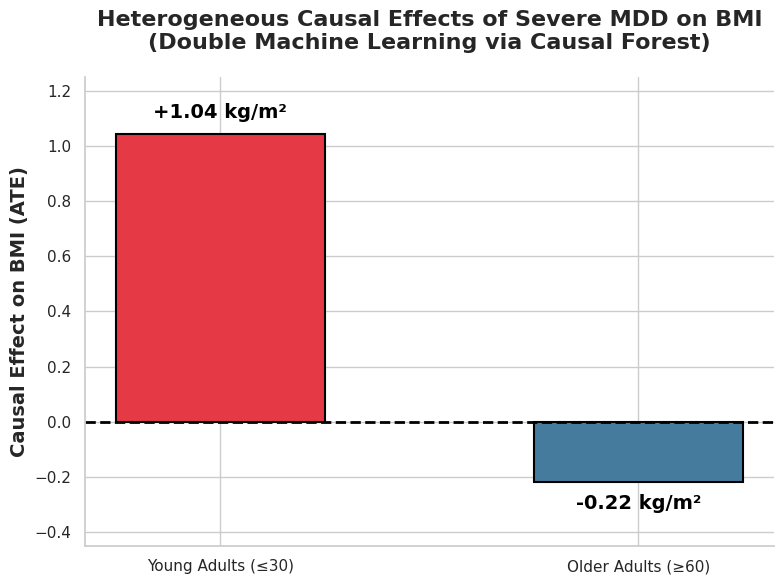

✅ 高清柱状图已修复重叠问题，并重新保存！


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置学术风格
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

# 提取我们在 DML 中计算出的异质性数据 (CATE)
groups = ['Young Adults (≤30)', 'Older Adults (≥60)']
cate_values = [young_cate, old_cate]  # 这里假设变量已经是 1.04 和 -0.22

# 创建画布
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制柱状图
colors = ['#E63946', '#457B9D']
bars = ax.bar(groups, cate_values, color=colors, width=0.5, edgecolor='black', linewidth=1.5)

# 添加 0 基准线
ax.axhline(0, color='black', linewidth=2, linestyle='--')

# 🛠️ 核心修复：强行拓宽 Y 轴的显示范围，给负值文字留出空间！
# 向上留到 1.3，向下留到 -0.5
ax.set_ylim(-0.45, 1.25)

# 在柱子上方/下方添加具体的数值标签
for bar, value in zip(bars, cate_values):
    # 根据正负值调整标签位置，负值再往下挪一点点，但因为有了 ylim，就不会和 X 轴撞了
    y_offset = 0.04 if value > 0 else -0.04
    ax.text(bar.get_x() + bar.get_width() / 2, value + y_offset,
            f'{value:+.2f} kg/m²',
            ha='center', va='bottom' if value > 0 else 'top',
            fontsize=14, fontweight='bold', color='black')

# 美化图表
ax.set_ylabel('Causal Effect on BMI (ATE)', fontweight='bold')
ax.set_title('Heterogeneous Causal Effects of Severe MDD on BMI\n(Double Machine Learning via Causal Forest)',
             pad=20, fontweight='bold')

# 去除上方和右侧的边框线
sns.despine()

# 紧凑布局并显示
plt.tight_layout()
plt.savefig('CATE_Age_Difference.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 高清柱状图已修复重叠问题，并重新保存！")